<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [ ]:
!pip install scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data
Y = data.target

X_treino, X_teste, Y_treino, Y_teste = train_test_split(
    X,
    Y,
    test_size= 0.2,
    stratify= Y,
    random_state= 42
)

print("Treino:", X_treino.shape)
print("Teste:", X_teste.shape)

Treino: (120, 4)
Teste: (30, 4)


In [ ]:
data
# para descobrir qual o atributo da raiz da minha arvora da questao 3

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
modelo = DecisionTreeClassifier()

modelo.fit(X_treino, Y_treino)

Y_pred_treino = modelo.predict(X_treino)
Y_pred_teste = modelo.predict(X_teste)

acuracia_treino = accuracy_score(Y_treino, Y_pred_treino)
acuracia_teste = accuracy_score(Y_teste, Y_pred_teste)

print("Acuracia de treino: ", acuracia_treino)
print("Acuracia de teste: ", acuracia_teste)

Acuracia de treino:  1.0
Acuracia de teste:  0.9666666666666667


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

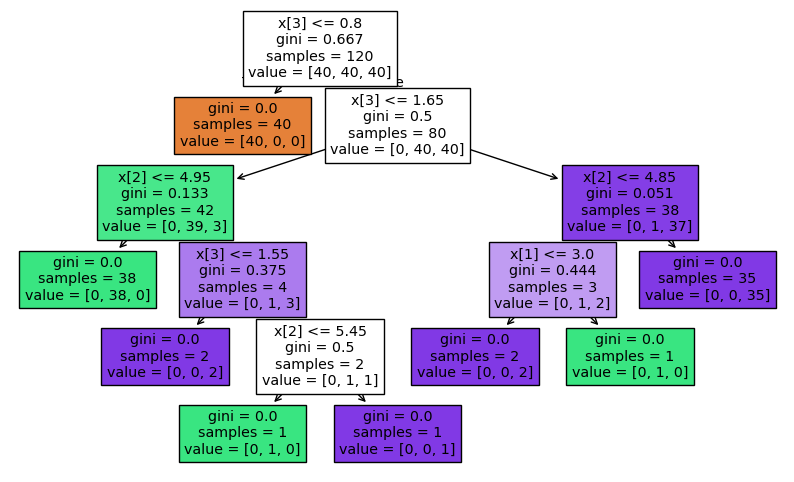

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plot_tree(modelo, filled=True)
plt.show()

print("A profundidade da árvore é 5")
print("O atributo da raiz da árvore é x=3 é petal width")

A profundidade da árvore é 5.
O atributo da raiz da árvore é x=3 é petal width

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [17]:
import pandas as pd

profundidades = [1,2,3,4,5,6,7,8,9,None]

resultados = []

for profundidade in profundidades:
    arvore = DecisionTreeClassifier(max_depth=profundidade, random_state=42)

    arvore.fit(X_treino, Y_treino)
    
    acc_treino = arvore.score(X_treino, Y_treino)
    acc_teste = arvore.score(X_teste, Y_teste)
    
    profundidade_real = arvore.get_depth()
    numero_folhas = arvore.get_n_leaves()
    
    resultados.append({
        "max_depth": profundidade,
        "acuracia_treino": acc_treino,
        "acuracia_teste": acc_teste,
        "profundidade_arvore": profundidade_real,
        "numero_folhas": numero_folhas
    })

tabela_resultados = pd.DataFrame(resultados)
pd.set_option('display.max_columns', None)
print(tabela_resultados)

   max_depth  acuracia_treino  acuracia_teste  profundidade_arvore  \
0        1.0         0.666667        0.666667                    1   
1        2.0         0.966667        0.933333                    2   
2        3.0         0.983333        0.966667                    3   
3        4.0         0.991667        0.933333                    4   
4        5.0         1.000000        0.933333                    5   
5        6.0         1.000000        0.933333                    5   
6        7.0         1.000000        0.933333                    5   
7        8.0         1.000000        0.933333                    5   
8        9.0         1.000000        0.933333                    5   
9        NaN         1.000000        0.933333                    5   

   numero_folhas  
0              2  
1              3  
2              5  
3              7  
4              8  
5              8  
6              8  
7              8  
8              8  
9              8  


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

O overfitting começa aproximadamente na profundidade 4 ou 5, quando a acurácia de treino continua aumentando enquanto a acurácia de teste para de melhorar ou começa a diminuir.
Porque não existe limite de profundidade. A árvore continua criando divisões até separar completamente os dados de treino, fazendo com que cada folha contenha apenas exemplos de uma única classe, o que leva a 100% de acurácia no treino.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [18]:
resultados = []

criterios = ["gini", "entropy"]

for criterio in criterios:
    
    arvore = DecisionTreeClassifier(
        criterion=criterio,
        random_state=42
    )
    
    arvore.fit(X_treino, Y_treino)
    
    acc_treino = arvore.score(X_treino, Y_treino)
    acc_teste = arvore.score(X_teste, Y_teste)
    
    profundidade = arvore.get_depth()
    
    resultados.append({
        "criterio": criterio,
        "acuracia_treino": acc_treino,
        "acuracia_teste": acc_teste,
        "profundidade_arvore": profundidade
    })

tabela = pd.DataFrame(resultados)

print(tabela)

  criterio  acuracia_treino  acuracia_teste  profundidade_arvore
0     gini              1.0        0.933333                    5
1  entropy              1.0        0.933333                    5


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [19]:
profundidades = [1,2,3,4,5,6,7,8,9,None]

resultados = []

for d in profundidades:
    
    modelo = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )
    
    modelo.fit(X_treino, Y_treino)
    
    acc_treino = modelo.score(X_treino, Y_treino)
    acc_teste = modelo.score(X_teste, Y_teste)
    
    resultados.append({
        "max_depth": d,
        "acuracia_treino": acc_treino,
        "acuracia_teste": acc_teste
    })

tabela = pd.DataFrame(resultados)

print(tabela)

   max_depth  acuracia_treino  acuracia_teste
0        1.0         0.666667        0.666667
1        2.0         0.966667        0.933333
2        3.0         0.983333        0.966667
3        4.0         0.991667        0.933333
4        5.0         1.000000        0.933333
5        6.0         1.000000        0.933333
6        7.0         1.000000        0.933333
7        8.0         1.000000        0.933333
8        9.0         1.000000        0.933333
9        NaN         1.000000        0.933333


# para a questao 6

Foi investigado o hiperparâmetro max_depth, que controla a profundidade máxima da árvore. Observou-se que, conforme a profundidade aumenta, a acurácia de treino tende a aumentar, pois o modelo se ajusta melhor aos dados. Porém, após certa profundidade, a acurácia de teste não melhora e pode até diminuir, indicando overfitting. O melhor modelo encontrado foi com max_depth = 3, que apresentou a maior acurácia no conjunto de teste (≈0.96).